In [ ]:
# Instalando os pacotes

!pip install pandas
!pip install numpy
!pip install factor_analyzer
!pip install sympy
!pip install scipy
!pip install matplotlib
!pip install seaborn
!pip install plotly
!pip install pingouin
!pip install pyshp

In [ ]:
# Importando os pacotes necessários

import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
pio.renderers.default = 'notebook'
import plotly.graph_objects as go
import shapefile as shp

In [ ]:
# Importando o banco de dados

dados = pd.read_excel("emprestimo_banco.xlsx")

print(dados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          5000 non-null   int64  
 1   Age         5000 non-null   int64  
 2   Experience  5000 non-null   int64  
 3   Income      5000 non-null   int64  
 4   Family      5000 non-null   int64  
 5   CCAvg       5000 non-null   float64
 6   Mortgage    5000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 273.6 KB
None


In [ ]:
# Separando somente as variáveis quantitativas do banco de dados

# dados_pca = dados[["", "", "", ""]]

# Outra maneira de separar somente as variáveis quantitativas do banco de dados

dados_pca = dados.drop(columns=['ID'])

In [ ]:
# Matriz de correlações de Pearson entre as variáveis

pg.rcorr(dados_pca, method = 'pearson', upper = 'pval',
         decimals = 4,
         pval_stars = {0.01: '***', 0.05: '**', 0.10: '*'})

# Outra maneira de analisar as informações das correlações

# Matriz de correlações em um objeto "simples"

correlacao = dados_pca.corr()

print(correlacao)

                 Age  Experience    Income    Family     CCAvg  Mortgage
Age         1.000000    0.994198 -0.055269 -0.046418 -0.052030 -0.012539
Experience  0.994198    1.000000 -0.046729 -0.052213 -0.049925 -0.010840
Income     -0.055269   -0.046729  1.000000 -0.157501  0.645993  0.206806
Family     -0.046418   -0.052213 -0.157501  1.000000 -0.109285 -0.020445
CCAvg      -0.052030   -0.049925  0.645993 -0.109285  1.000000  0.109909
Mortgage   -0.012539   -0.010840  0.206806 -0.020445  0.109909  1.000000


In [ ]:
# Gráfico interativo

fig = go.Figure()

fig.add_trace(
    go.Heatmap(
        x = correlacao.columns,
        y = correlacao.index,
        z = np.array(correlacao),
        text=correlacao.values,
        texttemplate='%{text:.4f}',
        colorscale='viridis'))

fig.update_layout(
    height = 600,
    width = 600,
    yaxis=dict(autorange="reversed"))

fig.show()

In [ ]:
# Teste de Esfericidade de Bartlett

bartlett, p_value = calculate_bartlett_sphericity(dados_pca)

print(f'Qui² Bartlett: {round(bartlett, 2)}')
print(f'p-valor: {round(p_value, 4)}')

Qui² Bartlett: 25409.78
p-valor: 0.0


In [ ]:
# Definindo a PCA (procedimento inicial com todos os fatores possíveis)

# fa = FactorAnalyzer(n_factors=2, method='principal', rotation=None).fit(dados_pca)

# Em certos casos, a "rotação de fatores" pode melhorar a interpretação

# Analisando pelo loading plot, aplica-se a rotação dos eixos na origem (0,0)
# O método mais comum é a 'varimax', que é a rotação ortogonal dos fatores
# O objetivo é aumentar a carga fatorial em um fator e diminuir em outro
# Em resumo, trata-se de uma redistribuição de cargas fatoriais

# Adicionando a rotação: rotation='varimax'

fa = FactorAnalyzer(n_factors= 2, method='principal', rotation='varimax').fit(dados_pca)

# Obtendo os eigenvalues (autovalores): resultantes da função FactorAnalyzer

autovalores = fa.get_eigenvalues()[0]

print(autovalores)

# Soma dos autovalores

round(autovalores.sum(), 2)


[2.02800719 1.73665956 0.97645432 0.90872121 0.34441264 0.00574507]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



np.float64(6.0)

In [ ]:
# Eigenvalues, variâncias e variâncias acumuladas

autovalores_fatores = fa.get_factor_variance()

tabela_eigen = pd.DataFrame(autovalores_fatores)
tabela_eigen.columns = [f"Fator {i+1}" for i, v in enumerate(tabela_eigen.columns)]
tabela_eigen.index = ['Autovalor','Variância', 'Variância Acumulada']
tabela_eigen = tabela_eigen.T

print(tabela_eigen)

         Autovalor  Variância  Variância Acumulada
Fator 1   2.007323   0.334554             0.334554
Fator 2   1.757344   0.292891             0.627444


<ipython-input-46-d8e401c9fc2b>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




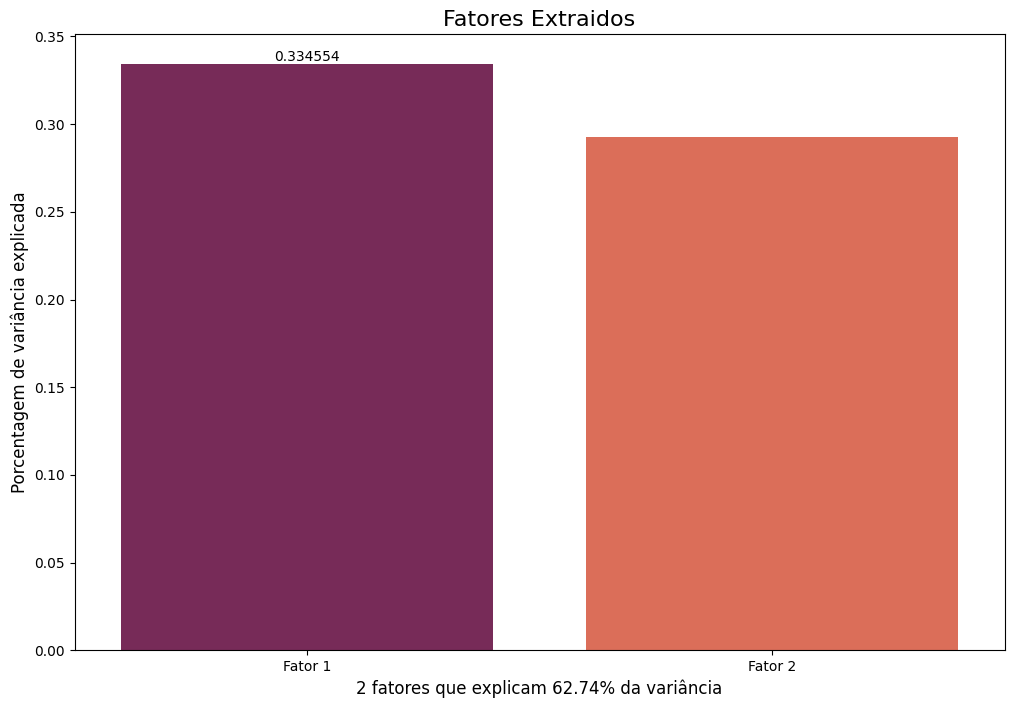

In [ ]:
# Gráfico da variância acumulada dos componentes principais

plt.figure(figsize=(12,8))
ax = sns.barplot(x=tabela_eigen.index, y=tabela_eigen['Variância'], data=tabela_eigen, palette='rocket')
ax.bar_label(ax.containers[0])
plt.title("Fatores Extraidos", fontsize=16)
plt.xlabel(f"{tabela_eigen.shape[0]} fatores que explicam {round(tabela_eigen['Variância'].sum()*100,2)}% da variância", fontsize=12)
plt.ylabel("Porcentagem de variância explicada", fontsize=12)
plt.show()


In [ ]:
# Determinando as cargas fatoriais

cargas_fatoriais = fa.loadings_

tabela_cargas = pd.DataFrame(cargas_fatoriais)
tabela_cargas.columns = [f"Fator {i+1}" for i, v in enumerate(tabela_cargas.columns)]
tabela_cargas.index = dados_pca.columns

print(tabela_cargas)

             Fator 1   Fator 2
Age         0.996570  0.005748
Experience  0.996745  0.012552
Income     -0.067999  0.887373
Family     -0.103275 -0.328699
CCAvg      -0.071784  0.850122
Mortgage   -0.015137  0.372790


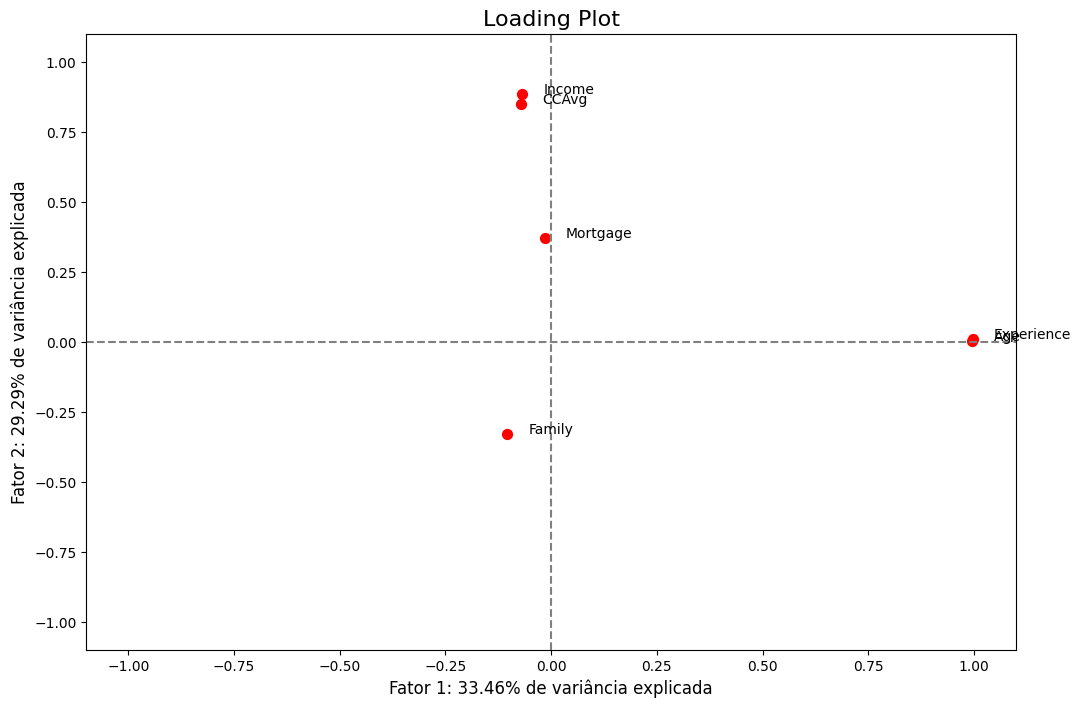

In [ ]:
# Gráfico das cargas fatoriais (loading plot)

plt.figure(figsize=(12,8))
tabela_cargas_chart = tabela_cargas.reset_index()
plt.scatter(tabela_cargas_chart['Fator 1'], tabela_cargas_chart['Fator 2'], s=50, color='red')

def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x'] + 0.05, point['y'], point['val'])

label_point(x = tabela_cargas_chart['Fator 1'],
            y = tabela_cargas_chart['Fator 2'],
            val = tabela_cargas_chart['index'],
            ax = plt.gca())

plt.axhline(y=0, color='grey', ls='--')
plt.axvline(x=0, color='grey', ls='--')
plt.ylim([-1.1,1.1])
plt.xlim([-1.1,1.1])
plt.title("Loading Plot", fontsize=16)
plt.xlabel(f"Fator 1: {round(tabela_eigen.iloc[0]['Variância']*100,2)}% de variância explicada", fontsize=12)
plt.ylabel(f"Fator 2: {round(tabela_eigen.iloc[1]['Variância']*100,2)}% de variância explicada", fontsize=12)
plt.show()


In [ ]:
# Determinando as comunalidades

comunalidades = fa.get_communalities()

tabela_comunalidades = pd.DataFrame(comunalidades)
tabela_comunalidades.columns = ['Comunalidades']
tabela_comunalidades.index = dados_pca.columns

print(tabela_comunalidades)

            Comunalidades
Age              0.993184
Experience       0.993658
Income           0.792054
Family           0.118709
CCAvg            0.727860
Mortgage         0.139201


In [ ]:
# Extração dos fatores para as observações do banco de dados

fatores = pd.DataFrame(fa.transform(dados_pca))
fatores.columns =  [f"Fator {i+1}" for i, v in enumerate(fatores.columns)]

# Adicionando os fatores ao banco de dados

dados = pd.concat([dados.reset_index(drop=True), fatores], axis=1)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
# Identificando os scores fatoriais

scores = fa.weights_

tabela_scores = pd.DataFrame(scores)
tabela_scores.columns = [f"Fator {i+1}" for i, v in enumerate(tabela_scores.columns)]
tabela_scores.index = dados_pca.columns

print(tabela_scores)


             Fator 1   Fator 2
Age         0.497378  0.024448
Experience  0.497610  0.028330
Income     -0.015077  0.504309
Family     -0.058514 -0.189535
CCAvg      -0.017757  0.482998
Mortgage    0.000367  0.212148


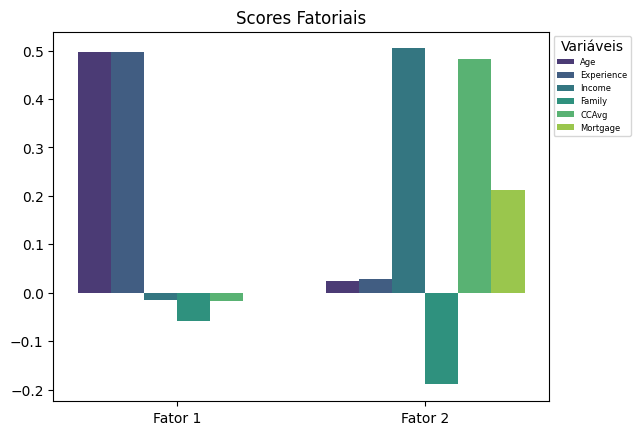

,Fator 1,Fator 2
Fator 1,-,
Fator 2,0.0,-


In [ ]:
# Interpretando os scores fatoriais em cada fator extraído

tabela_scores_graph = tabela_scores.reset_index()
tabela_scores_graph = tabela_scores_graph.melt(id_vars='index')

sns.barplot(data=tabela_scores_graph, x='variable', y='value', hue='index', palette='viridis')
plt.legend(title='Variáveis', bbox_to_anchor=(1,1), fontsize = '6')
plt.title('Scores Fatoriais', fontsize='12')
plt.xlabel(xlabel=None)
plt.ylabel(ylabel=None)
plt.show()

# Os fatores continuam ortogonais

pg.rcorr(dados[['Fator 1', 'Fator 2']],
         method = 'pearson', upper = 'pval',
         decimals = 4,
         pval_stars = {0.01: '***', 0.05: '**', 0.10: '*'})

# Fim!

In [ ]:
# Criando um ranking (soma ponderada e ordenamento)

# O ranking irá considerar apenas os 2 fatores com autovalores > 1
# A base de seleção é a tabela_eigen

dados['Ranking'] = 0

for index, item in enumerate(list(tabela_eigen.index)):
    variancia = tabela_eigen.loc[item]['Variância']

    dados['Ranking'] = dados['Ranking'] + dados[tabela_eigen.index[index]]*variancia

print(dados)

# Fim!

        ID  Age  Experience  Income  Family  CCAvg  Mortgage   Fator 1  \
0        1   25           1      49       4    1.6         0 -1.784680   
1        2   45          19      34       3    1.5         0 -0.076890   
2        3   39          15      11       1    1.0         0 -0.396656   
3        4   35           9     100       1    2.7         0 -0.877657   
4        5   35           8      45       4    1.0         0 -1.038838   
...    ...  ...         ...     ...     ...    ...       ...       ...   
4995  4996   29           3      40       1    1.9         0 -1.371235   
4996  4997   30           4      15       4    0.4        85 -1.413575   
4997  4998   63          39      24       2    0.3         0  1.640653   
4998  4999   65          40      49       3    0.5         0  1.709728   
4999  5000   28           4      83       3    0.8         0 -1.476017   

       Fator 2   Ranking  
0    -0.838273 -0.842594  
1    -0.777857 -0.253551  
2    -0.860423 -0.384713  
3  